<a href="https://colab.research.google.com/github/schadmichael/ParsingQuotes/blob/main/index_probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-2739973702.py:52: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  shares += initial_investment_amount / float(window.iloc[0])
/tmp/ipython-input-2739973702.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  shares += dca_amount / float(px)
/tmp/ipython-input-2739973702.py:62: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  final_value = shares * float(window.iloc[-1])


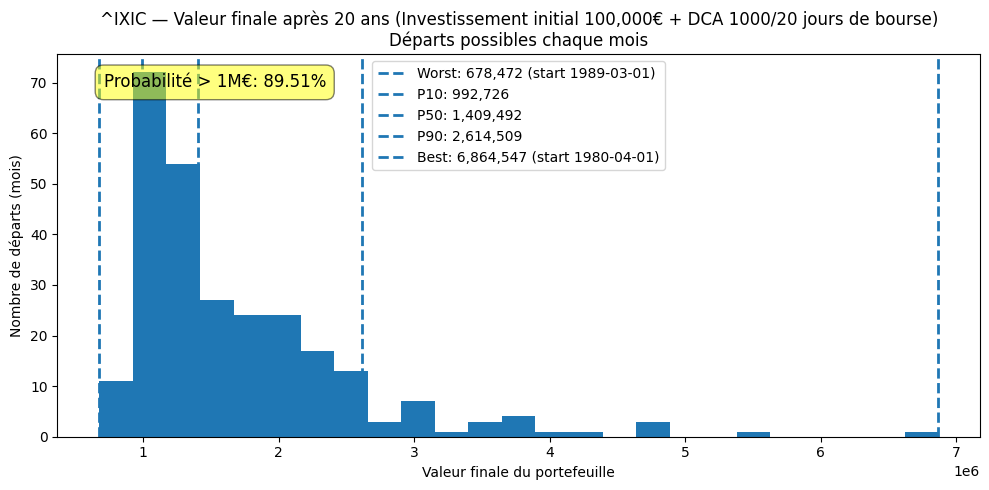

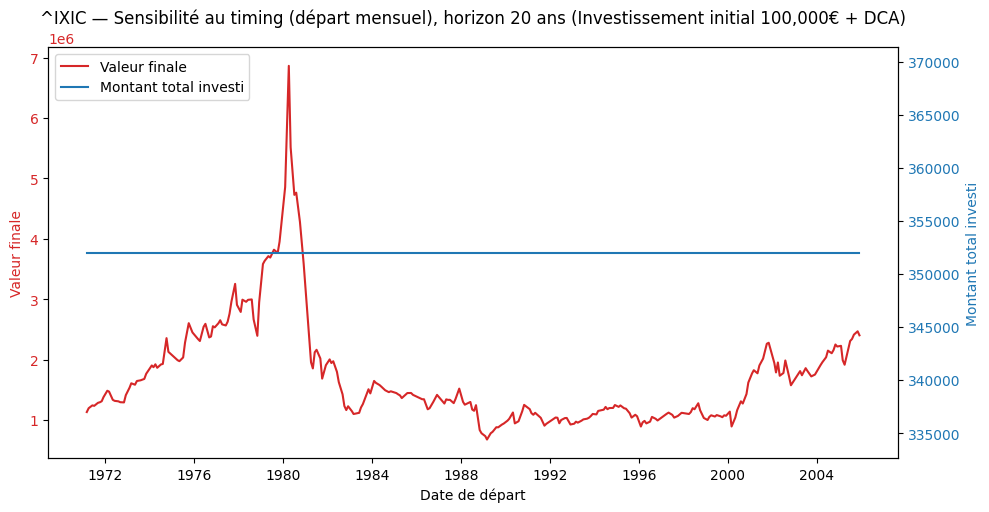

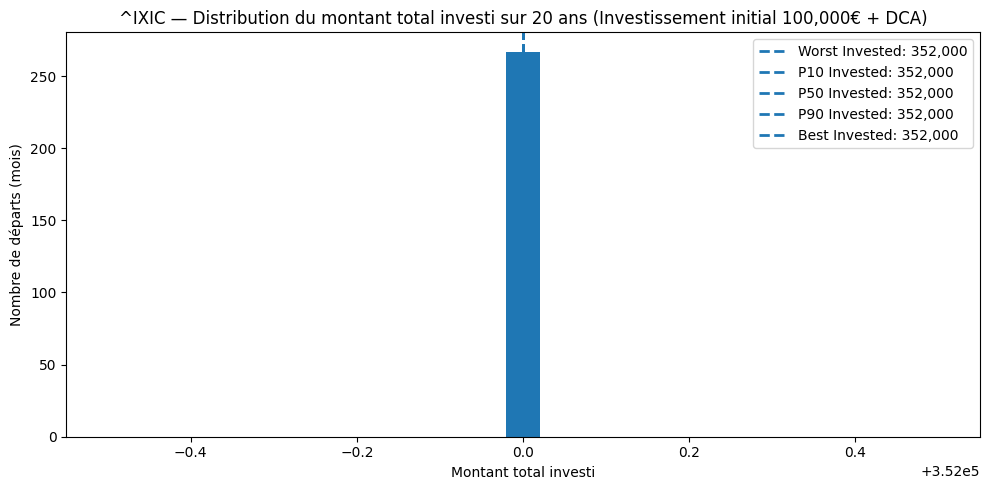

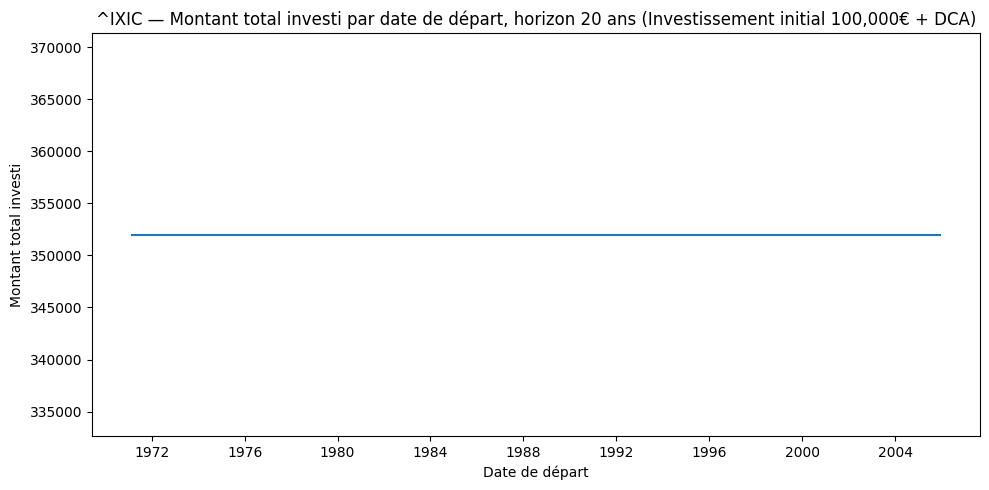

^IXIC sur Yahoo Finance | horizon 20 ans | Investissement initial 100,000€ + DCA 1000 tous les 20 jours de bourse
Nombre de fenêtres testées: 267
--- Valeur finale ---
Worst-case: 678,472 (départ 1989-03-01)
P10: 992,726 | P50: 1,409,492 | P90: 2,614,509
Best-case: 6,864,547 (départ 1980-04-01)
--- Montant total investi ---
Worst-case investi: 352,000
P10 investi: 352,000 | P50 investi: 352,000 | P90 investi: 352,000
Best-case investi: 352,000


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# -----------------------
# Params
# -----------------------
ticker = "^IXIC"             # proxy S&P 500 (ETF) GSPC IXIC
start_download = "1946-01-01"
how_many_years_to_backtest = 20
dca_amount = 1000          # € (peu importe la devise pour le raisonnement si on reste cohérent)
dca_every_trading_days = 20
initial_investment_amount = 100000 # New parameter for initial lump sum investment

# -----------------------
# Data (Yahoo Finance)
# -----------------------
df = yf.download(ticker, start=start_download, auto_adjust=True, progress=False)
prices = df["Close"].dropna()

# Monthly starting points (first trading day of each month in the dataset)
monthly_first = prices.resample("MS").first()
start_dates = monthly_first.index

horizon_trading_days = how_many_years_to_backtest * 252  # approx number of trading days in a year

final_values = []
total_invested_values = [] # New list to store total invested amount for each window
valid_starts = []

# -----------------------
# Rolling backtest: start each month, run X years, DCA every 20 trading days
# -----------------------
for start in start_dates:
    # if start not a trading day for some reason, skip
    if start not in prices.index:
        continue

    start_loc = prices.index.get_loc(start)
    end_loc = start_loc + horizon_trading_days

    if end_loc >= len(prices):
        break  # no more complete 20y windows

    window = prices.iloc[start_loc:end_loc + 1]

    shares = 0.0
    current_window_invested = 0.0

    # Apply initial lump sum investment at the very first trading day of the window
    shares += initial_investment_amount / float(window.iloc[0])
    current_window_invested += initial_investment_amount

    # Apply DCA investments for subsequent periods
    for i, px in enumerate(window.values):
        # DCA happens every 'dca_every_trading_days', but we skip i=0 as initial investment is already handled
        if i > 0 and i % dca_every_trading_days == 0:
            shares += dca_amount / float(px)
            current_window_invested += dca_amount

    final_value = shares * float(window.iloc[-1])
    final_values.append(final_value)
    total_invested_values.append(current_window_invested) # Store total invested for this window
    valid_starts.append(start)

results = pd.Series(final_values, index=pd.DatetimeIndex(valid_starts), name="final_value")
total_invested_series = pd.Series(total_invested_values, index=pd.DatetimeIndex(valid_starts), name="total_invested")

# -----------------------
# Stats for annotations (Final Value)
# -----------------------
p10_fv, p50_fv, p90_fv = np.percentile(results.values, [10, 50, 90])
worst_fv = results.min()
best_fv = results.max()
worst_date_fv = results.idxmin()
best_date_fv = results.idxmax()

# -----------------------
# Stats for annotations (Total Invested)
# -----------------------
p10_ti, p50_ti, p90_ti = np.percentile(total_invested_series.values, [10, 50, 90])
worst_ti = total_invested_series.min()
best_ti = total_invested_series.max()
worst_date_ti = total_invested_series.idxmin()
best_date_ti = total_invested_series.idxmax()

# -----------------------
# Calculate probability of exceeding 1M (for annotation)
# -----------------------
threshold = 1000000
exceed_threshold_count = (results > threshold).sum()
total_simulations = len(results)
probability_exceeding_1m = (exceed_threshold_count / total_simulations) * 100

# -----------------------
# Plot 1: Distribution + percentiles + worst-case (Final Value)
# -----------------------
plt.figure(figsize=(10, 5))
plt.hist(results.values, bins=25)
plt.axvline(worst_fv, linestyle="--", linewidth=2, label=f"Worst: {worst_fv:,.0f} (start {worst_date_fv.date()})")
plt.axvline(p10_fv, linestyle="--", linewidth=2, label=f"P10: {p10_fv:,.0f}")
plt.axvline(p50_fv, linestyle="--", linewidth=2, label=f"P50: {p50_fv:,.0f}")
plt.axvline(p90_fv, linestyle="--", linewidth=2, label=f"P90: {p90_fv:,.0f}")
plt.axvline(best_fv, linestyle="--", linewidth=2, label=f"Best: {best_fv:,.0f} (start {best_date_fv.date()})")

plt.title(f"{ticker} — Valeur finale après {how_many_years_to_backtest} ans (Investissement initial {initial_investment_amount:,}€ + DCA {dca_amount}/20 jours de bourse)\nDéparts possibles chaque mois")
plt.xlabel("Valeur finale du portefeuille")
plt.ylabel("Nombre de départs (mois)")
plt.legend()

# Add probability annotation
plt.text(0.05, 0.95, f'Probabilité > 1M€: {probability_exceeding_1m:.2f}%', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

# -----------------------
# Plot 2: Final value and Total Invested by start date (timing sensitivity)
# -----------------------
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Date de départ')
ax1.set_ylabel('Valeur finale', color=color)
ax1.plot(results.index, results.values, color=color, label='Valeur finale')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Montant total investi', color=color)  # we already handled the x-label with ax1
ax2.plot(total_invested_series.index, total_invested_series.values, color=color, label='Montant total investi')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title(f"{ticker} — Sensibilité au timing (départ mensuel), horizon {how_many_years_to_backtest} ans (Investissement initial {initial_investment_amount:,}€ + DCA)")
# Add legend from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
plt.legend(handles1 + handles2, labels1 + labels2, loc='upper left')
plt.show()

# -----------------------
# Plot 3: Distribution + percentiles (Total Invested)
# -----------------------
plt.figure(figsize=(10, 5))
plt.hist(total_invested_series.values, bins=25)
plt.axvline(worst_ti, linestyle="--", linewidth=2, label=f"Worst Invested: {worst_ti:,.0f}")
plt.axvline(p10_ti, linestyle="--", linewidth=2, label=f"P10 Invested: {p10_ti:,.0f}")
plt.axvline(p50_ti, linestyle="--", linewidth=2, label=f"P50 Invested: {p50_ti:,.0f}")
plt.axvline(p90_ti, linestyle="--", linewidth=2, label=f"P90 Invested: {p90_ti:,.0f}")
plt.axvline(best_ti, linestyle="--", linewidth=2, label=f"Best Invested: {best_ti:,.0f}")
plt.title(f"{ticker} — Distribution du montant total investi sur {how_many_years_to_backtest} ans (Investissement initial {initial_investment_amount:,}€ + DCA)")
plt.xlabel("Montant total investi")
plt.ylabel("Nombre de départs (mois)")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------
# Plot 4: Total Invested by start date (timing sensitivity) - This plot is now redundant but kept for now
# -----------------------
plt.figure(figsize=(10, 5))
plt.plot(total_invested_series.index, total_invested_series.values)
plt.title(f"{ticker} — Montant total investi par date de départ, horizon {how_many_years_to_backtest} ans (Investissement initial {initial_investment_amount:,}€ + DCA)")
plt.xlabel("Date de départ")
plt.ylabel("Montant total investi")
plt.tight_layout()
plt.show()

# -----------------------
# Quick text summary to paste in your post
# -----------------------
summary = (
    f"{ticker} sur Yahoo Finance | horizon {how_many_years_to_backtest} ans | Investissement initial {initial_investment_amount:,}€ + DCA {dca_amount} tous les 20 jours de bourse\n"
    f"Nombre de fenêtres testées: {len(results)}\n"
    f"--- Valeur finale ---\n"
    f"Worst-case: {worst_fv:,.0f} (départ {worst_date_fv.date()})\n"
    f"P10: {p10_fv:,.0f} | P50: {p50_fv:,.0f} | P90: {p90_fv:,.0f}\n"
    f"Best-case: {best_fv:,.0f} (départ {best_date_fv.date()})\n"
    f"--- Montant total investi ---\n"
    f"Worst-case investi: {worst_ti:,.0f}\n"
    f"P10 investi: {p10_ti:,.0f} | P50 investi: {p50_ti:,.0f} | P90 investi: {p90_ti:,.0f}\n"
    f"Best-case investi: {best_ti:,.0f}"
)
print(summary)

In [27]:
# Calculate the probability of exceeding 1 million
threshold = 1000000
exceed_threshold_count = (results > threshold).sum()
total_simulations = len(results)
probability_exceeding_1m = (exceed_threshold_count / total_simulations) * 100

print(f"Probabilité historique de dépasser {threshold:,.0f} €: {probability_exceeding_1m:.2f}%")

Probabilité historique de dépasser 1,000,000 €: 100.00%


In [37]:
# Accessing the worst and best case dates from the previous execution
worst_date = worst_date_fv.date() # Defined in cell SVDe_lon9Upz
best_date = best_date_fv.date() # Defined in cell SVDe_lon9Upz

print(f"For the worst-case starting date ({worst_date}):")
print(f"Suggested search query: \"economic events {worst_date.year}\" \"stock market news {worst_date.year}\"\n")

print(f"For the best-case starting date ({best_date}):")
print(f"Suggested search query: \"economic events {best_date.year}\" \"stock market news {best_date.year}\"\n")


For the worst-case starting date (1989-03-01):
Suggested search query: "economic events 1989" "stock market news 1989"

For the best-case starting date (1980-04-01):
Suggested search query: "economic events 1980" "stock market news 1980"



In [38]:
# Accessing the worst and best case dates from the previous execution
worst_date = worst_date_fv.date() # Defined in cell SVDe_lon9Upz
best_date = best_date_fv.date() # Defined in cell SVDe_lon9Upz

print(f"For the worst-case starting date ({worst_date}):")
print(f"Suggested search query: \"economic events {worst_date.year}\" \"stock market news {worst_date.year}\"\n")

print(f"For the best-case starting date ({best_date}):")
print(f"Suggested search query: \"economic events {best_date.year}\" \"stock market news {best_date.year}\"\n")


For the worst-case starting date (1989-03-01):
Suggested search query: "economic events 1989" "stock market news 1989"

For the best-case starting date (1980-04-01):
Suggested search query: "economic events 1980" "stock market news 1980"

